In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/global-billionaire-wealth-to-gdp-2026/billionaire_country_aggregate_2026.csv
/kaggle/input/datasets/kanchana1990/global-billionaire-wealth-to-gdp-2026/billionaire_individual_2026.csv


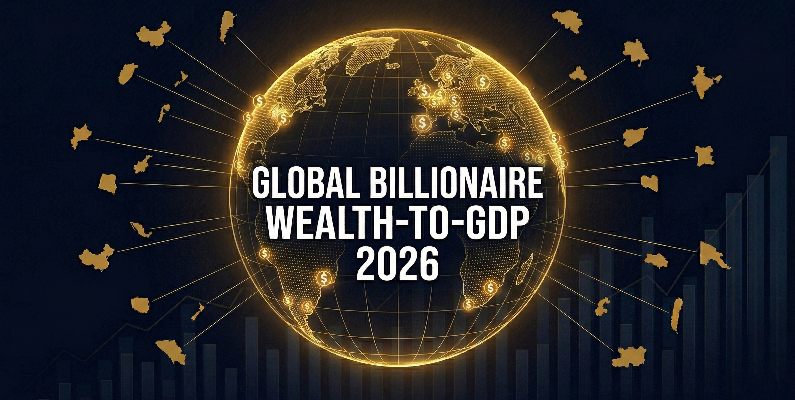!

In [2]:
import pandas as pd

df_indivisual=pd.read_csv('/kaggle/input/datasets/kanchana1990/global-billionaire-wealth-to-gdp-2026/billionaire_individual_2026.csv')

df_aggregate=pd.read_csv('/kaggle/input/datasets/kanchana1990/global-billionaire-wealth-to-gdp-2026/billionaire_country_aggregate_2026.csv')

df_indivisual.head(5)

,rank,person_name,gender,age,country,iso3,wb_country_name,state,city,net_worth_usd_m,...,wealth_gdp_ratio_pct,wealth_per_citizen_usd,wealth_country_share_pct,sector_dominance_score,gdp_usd,population,gdp_year,forbes_uri,scrape_timestamp,birth_year
0,1,Elon Musk,M,54.0,United States,USA,United States,Texas,Austin,800629.06,...,2.784704,2354.0229,9.5966,23.35,2.875096e+13,340110988.0,2024.0,elon-musk,2026-04-10 21:32 UTC,1971.0
1,2,Larry Page,M,53.0,United States,USA,United States,California,Palo Alto,260898.20,...,0.907442,767.0972,3.1272,23.35,2.875096e+13,340110988.0,2024.0,larry-page,2026-04-10 21:32 UTC,1973.0
2,3,Jeff Bezos,M,62.0,United States,USA,United States,Florida,Miami,248778.91,...,0.865289,731.4639,2.9819,23.35,2.875096e+13,340110988.0,2024.0,jeff-bezos,2026-04-10 21:32 UTC,1964.0
3,4,Sergey Brin,M,52.0,United States,USA,United States,California,Los Altos,240743.24,...,0.837340,707.8373,2.8856,23.35,2.875096e+13,340110988.0,2024.0,sergey-brin,2026-04-10 21:32 UTC,1973.0
4,5,Mark Zuckerberg,M,41.0,United States,USA,United States,California,Palo Alto,216089.31,...,0.751590,635.3494,2.5901,23.35,2.875096e+13,340110988.0,2024.0,mark-zuckerberg,2026-04-10 21:32 UTC,1984.0


In [3]:
df_aggregate.head()

,country_wealth_rank,country,iso3,wb_country_name,billionaire_count,total_wealth_usd_m,total_wealth_usd,mean_wealth_usd_m,median_wealth_usd_m,max_wealth_usd_m,...,self_made_ratio_pct,mean_age,country_wealth_gdp_pct,billionaires_per_million_pop,wealth_concentration_tier,gdp_per_billionaire_bn,sector_dominance_score,gdp_usd,population,gdp_year
0,1,United States,USA,United States,978,8342857.33,8.342857e+12,8530.528967,3075.915,800629.06,...,72.2,66.6,29.0177,2.8755,Very High (20–40%),29.40,23.35,2.875096e+13,3.401110e+08,2024.0
1,2,China,CHN,China,528,2134679.32,2.134679e+12,4042.953258,2047.715,69300.00,...,97.2,60.6,11.3887,0.3747,High (10–20%),35.50,15.26,1.874380e+13,1.408975e+09,2024.0
2,3,India,IND,India,225,989622.96,9.896230e+11,4398.324267,2284.800,94836.79,...,47.1,68.8,25.3108,0.1551,Very High (20–40%),17.38,12.20,3.909892e+12,1.450936e+09,2024.0
3,4,Germany,DEU,Germany,212,985821.88,9.858219e+11,4650.103208,2428.135,65613.88,...,26.9,61.2,21.0394,2.5384,Very High (20–40%),22.10,14.32,4.685593e+12,8.351659e+07,2024.0
4,5,Russia,RUS,Russian Federation,149,653326.62,6.533266e+11,4384.742416,1802.680,36946.33,...,94.0,60.9,30.0541,1.0381,Very High (20–40%),14.59,17.19,2.173836e+12,1.435339e+08,2024.0


<div style="
background-color: #1a1a1a;
color: #eee;
padding: 15px;
border-radius: 10px;
border-right: 6px solid yellow;
border-bottom: 6px solid yellow;
font-family: sans-serif;    
border-radius: 4px;
font-family: 'Courier New', monospace;
box-shadow: 4px 4px 8px rgba(255, 255, 0, 0.4);    
">
<span style="background: #ffff00; color: #000; padding: 2px 8px; font-weight: bold; border-radius: 3px; font-size: 12px;">STEP 02</span>
<h3 style="margin: 10px 0 5px 0; color: #ffff00;">DATA CLEANING</h3>
<p style="margin: 0; opacity: 0.8;">Module: Handling Missing Values </p>
</div>

In [4]:
df_indivisual.isnull().sum()

rank                           0
person_name                    0
gender                         0
age                           48
country                        0
iso3                           0
wb_country_name                0
state                       1842
city                          49
net_worth_usd_m                0
net_worth_usd                  0
source_of_wealth               0
industries                     0
primary_industry               0
self_made                      0
wealth_gdp_ratio_pct           4
wealth_per_citizen_usd         4
wealth_country_share_pct       0
sector_dominance_score         0
gdp_usd                        0
population                     0
gdp_year                       0
forbes_uri                     0
scrape_timestamp               0
birth_year                    48
dtype: int64

In [5]:
df_indivisual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3384 entries, 0 to 3383
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   rank                      3384 non-null   int64  
 1   person_name               3384 non-null   object 
 2   gender                    3384 non-null   object 
 3   age                       3336 non-null   float64
 4   country                   3384 non-null   object 
 5   iso3                      3384 non-null   object 
 6   wb_country_name           3384 non-null   object 
 7   state                     1542 non-null   object 
 8   city                      3335 non-null   object 
 9   net_worth_usd_m           3384 non-null   float64
 10  net_worth_usd             3384 non-null   float64
 11  source_of_wealth          3384 non-null   object 
 12  industries                3384 non-null   object 
 13  primary_industry          3384 non-null   object 
 14  self_mad

In [6]:
df_indivisual.describe()

,rank,age,net_worth_usd_m,net_worth_usd,wealth_gdp_ratio_pct,wealth_per_citizen_usd,wealth_country_share_pct,sector_dominance_score,gdp_usd,population,gdp_year,birth_year
count,3384.000000,3336.00000,3384.000000,3.384000e+03,3380.000000,3380.000000,3384.000000,3384.000000,3.384000e+03,3.384000e+03,3384.000000,3336.000000
mean,1692.304078,65.28807,5803.649439,5.803649e+09,0.813284,297.566164,2.364066,21.776962,1.242640e+13,4.477572e+08,2023.966017,1960.132194
std,976.985445,14.05242,19528.342838,1.952834e+10,14.907988,4726.584626,9.495648,10.948346,1.196503e+13,5.356155e+08,0.182837,14.041155
min,1.000000,20.00000,0.000000,0.000000e+00,0.001391,0.691900,0.000000,12.200000,1.122389e+09,3.863100e+04,2022.000000,1921.000000
25%,846.750000,57.00000,1566.835000,1.566839e+09,0.012394,4.427275,0.066500,15.260000,1.856366e+12,5.895270e+07,2024.000000,1950.000000
50%,1692.500000,66.00000,2446.150000,2.446150e+09,0.053525,15.950200,0.258300,20.460000,4.685593e+12,3.401110e+08,2024.000000,1960.000000
75%,2538.250000,75.00000,4954.830000,4.954832e+09,0.215378,67.395000,1.077325,23.350000,2.875096e+13,3.401110e+08,2024.000000,1969.000000
max,3381.000000,104.00000,800629.060000,8.006291e+11,757.313270,181457.208100,100.000000,100.000000,2.875096e+13,1.450936e+09,2024.000000,2005.000000


In [7]:
df_aggregate.isnull().sum()

country_wealth_rank             0
country                         0
iso3                            0
wb_country_name                 0
billionaire_count               0
total_wealth_usd_m              0
total_wealth_usd                0
mean_wealth_usd_m               0
median_wealth_usd_m             0
max_wealth_usd_m                0
top_billionaire                 0
dominant_industry_by_wealth     0
self_made_count                 0
self_made_ratio_pct             0
mean_age                        0
country_wealth_gdp_pct          0
billionaires_per_million_pop    0
wealth_concentration_tier       0
gdp_per_billionaire_bn          0
sector_dominance_score          0
gdp_usd                         0
population                      0
gdp_year                        0
dtype: int64

In [8]:
df_aggregate.describe()

,country_wealth_rank,billionaire_count,total_wealth_usd_m,total_wealth_usd,mean_wealth_usd_m,median_wealth_usd_m,max_wealth_usd_m,self_made_count,self_made_ratio_pct,mean_age,country_wealth_gdp_pct,billionaires_per_million_pop,gdp_per_billionaire_bn,sector_dominance_score,gdp_usd,population,gdp_year
count,80.0000,80.000000,8.000000e+01,8.000000e+01,80.000000,80.00000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.00000,8.000000e+01,8.000000e+01,80.000000
mean,40.5000,42.300000,2.454944e+05,2.454944e+11,4659.133086,3245.41725,33824.110125,28.187500,64.240000,65.625000,34.361238,2.885221,55.017375,52.79575,1.317496e+12,8.025818e+07,2023.912500
std,23.2379,126.768143,9.642768e+05,9.642768e+11,3007.336874,2623.32111,92616.022846,97.591384,31.231251,9.876176,104.626357,8.017171,62.463119,33.68380,3.838465e+12,2.276647e+08,0.325839
min,1.0000,1.000000,1.000000e+03,1.000000e+09,1000.000000,1000.00000,1000.000000,0.000000,0.000000,26.000000,0.349900,0.004000,0.560000,12.20000,1.122389e+09,3.863100e+04,2022.000000
25%,20.7500,2.000000,5.831183e+03,5.831181e+09,2675.146528,1931.34000,3836.620000,1.000000,44.450000,60.400000,5.380000,0.184525,20.575000,22.51500,1.036729e+11,5.534726e+06,2024.000000
50%,40.5000,8.000000,4.146425e+04,4.146425e+10,4201.367960,2458.06000,13930.455000,6.000000,67.450000,65.550000,11.018050,0.687400,38.170000,38.68000,3.858121e+11,1.940829e+07,2024.000000
75%,60.2500,40.750000,1.652375e+05,1.652375e+11,5373.952164,3474.23500,26974.357500,18.250000,100.000000,71.400000,20.396575,1.975900,65.535000,100.00000,9.224664e+11,6.021632e+07,2024.000000
max,80.0000,978.000000,8.342857e+06,8.342857e+12,17618.620000,17618.62000,800629.060000,706.000000,100.000000,94.000000,860.681700,51.771900,371.570000,100.00000,2.875096e+13,1.450936e+09,2024.000000


In [9]:
df_aggregate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country_wealth_rank           80 non-null     int64  
 1   country                       80 non-null     object 
 2   iso3                          80 non-null     object 
 3   wb_country_name               80 non-null     object 
 4   billionaire_count             80 non-null     int64  
 5   total_wealth_usd_m            80 non-null     float64
 6   total_wealth_usd              80 non-null     float64
 7   mean_wealth_usd_m             80 non-null     float64
 8   median_wealth_usd_m           80 non-null     float64
 9   max_wealth_usd_m              80 non-null     float64
 10  top_billionaire               80 non-null     object 
 11  dominant_industry_by_wealth   80 non-null     object 
 12  self_made_count               80 non-null     int64  
 13  self_ma

In [10]:
df_indivisual['age']=df_indivisual['age'].fillna(-1)

In [11]:
df_indivisual['state']=df_indivisual['state'].fillna('N/A')

In [12]:
df_indivisual['city']=df_indivisual['city'].fillna('Unknown')

In [13]:
df_indivisual['birth_year']=df_indivisual['birth_year'].fillna(-1)

In [14]:
df_indivisual['birth_year']=df_indivisual['birth_year'].fillna(-1)

In [15]:
df_indivisual['wealth_gdp_ratio_pct']=df_indivisual['wealth_gdp_ratio_pct'].fillna(0)

In [16]:
df_indivisual['wealth_per_citizen_usd']=df_indivisual['wealth_per_citizen_usd'].fillna(0)

In [17]:
df_indivisual.isnull().sum()

rank                        0
person_name                 0
gender                      0
age                         0
country                     0
iso3                        0
wb_country_name             0
state                       0
city                        0
net_worth_usd_m             0
net_worth_usd               0
source_of_wealth            0
industries                  0
primary_industry            0
self_made                   0
wealth_gdp_ratio_pct        0
wealth_per_citizen_usd      0
wealth_country_share_pct    0
sector_dominance_score      0
gdp_usd                     0
population                  0
gdp_year                    0
forbes_uri                  0
scrape_timestamp            0
birth_year                  0
dtype: int64

# -----------------------------------------------------------

<div style="
background-color: #1a1a1a;
color: #eee;
padding: 15px;
border-radius: 10px;
border-right: 6px solid yellow;
border-bottom: 6px solid yellow;
font-family: sans-serif;    
border-radius: 4px;
font-family: 'Courier New', monospace;
box-shadow: 4px 4px 8px rgba(255, 255, 0, 0.4);    
">
<span style="background: #ffff00; color: #000; padding: 2px 8px; font-weight: bold; border-radius: 3px; font-size: 12px;">STEP 03</span>
<h3 style="margin: 10px 0 5px 0; color: #ffff00;">DATA VISUALIZATION</h3>

</div>

<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
STEP 03
</span>

### <span style="color:#d63384;">DATA VISUALIZATION</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
📊 VISUALIZATION
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Top 10 Industries by Billionaire Count
</strong>
</div>

This section highlights the industries with the highest number of billionaires, helping identify where wealth concentration is strongest.

</details>

</div>

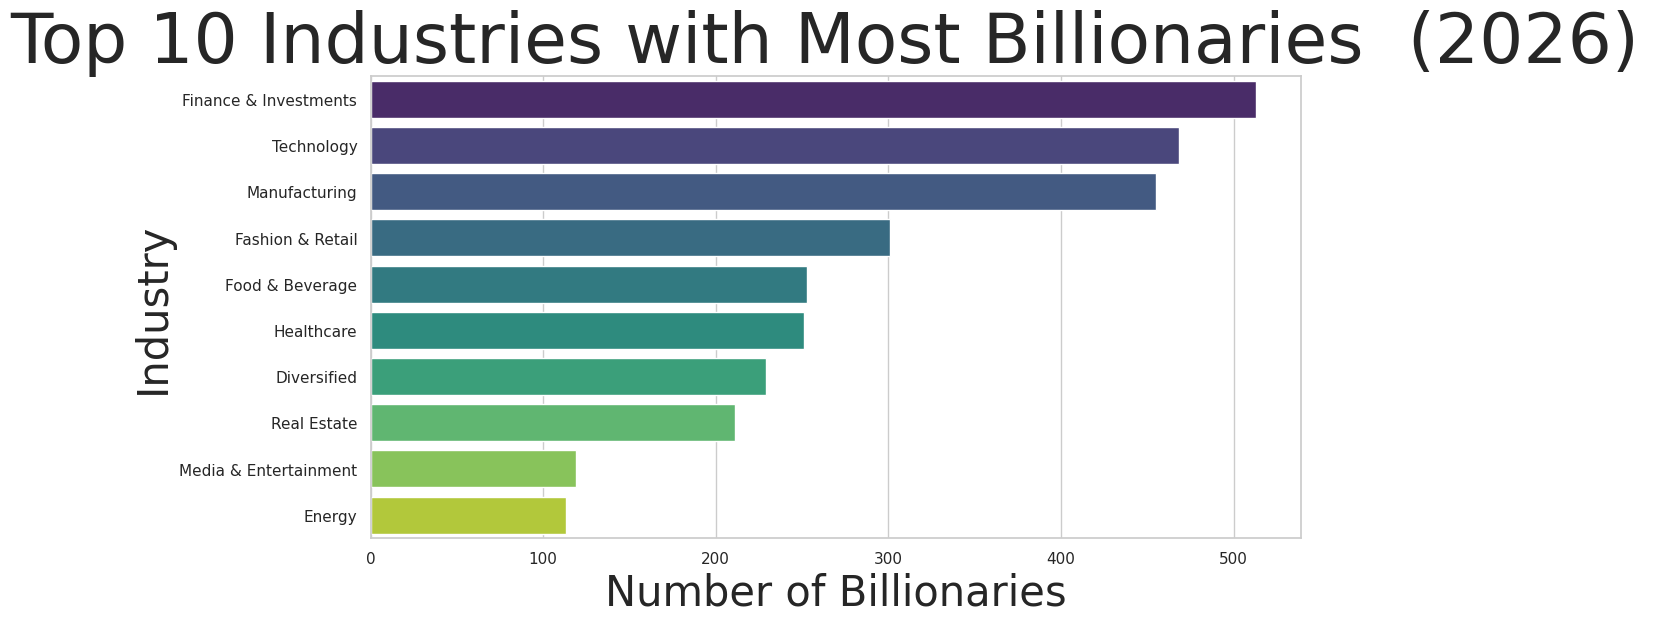

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))
top_industries=df_indivisual['primary_industry'].value_counts().head(10)

sns.barplot(x=top_industries.values,y=top_industries.index,hue=top_industries.index,palette='viridis',legend=False)

plt.title('Top 10 Industries with Most Billionaries  (2026) ',fontsize=50)
plt.xlabel('Number of Billionaries',fontsize=30)
plt.ylabel('Industry',fontsize=30)
plt.show()

<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
STEP 04
</span>

### <span style="color:#d63384;">WEALTH DISTRIBUTION</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
💰 DISTRIBUTION
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Wealth Distribution Overview
</strong>
</div>

This section explores how wealth is distributed across different segments, highlighting inequality and concentration patterns.

</details>

</div>

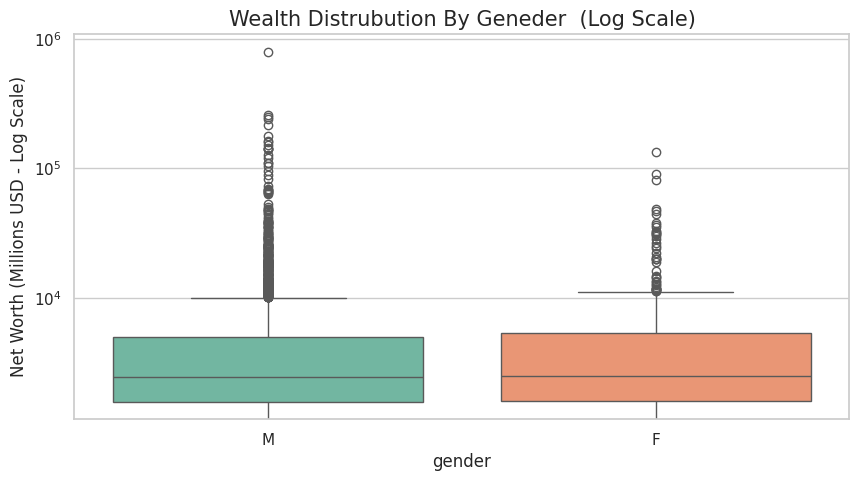

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_indivisual,x='gender',y='net_worth_usd_m',palette='Set2',hue='gender',legend=False)


plt.yscale('log')
plt.title('Wealth Distrubution By Geneder  (Log Scale)',fontsize=15)
plt.ylabel('Net Worth (Millions USD - Log Scale)')
plt.show()

<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
STEP 05
</span>

### <span style="color:#d63384;">GEOGRAPHICAL WEALTH MAP</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
🌍 MAP VIEW
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Global Wealth Distribution by Region
</strong>
</div>

This section visualizes how wealth is distributed across different countries and regions worldwide.

</details>

</div>

In [20]:
import plotly.express as px
fig=px.choropleth(df_aggregate,
                 locations="iso3",
                 color='total_wealth_usd_m',
                 hover_name="country",
                 title="Total Billionaire Wealth By country (2026)",
                 color_continuous_scale=px.colors.sequential.Plasma,
                 labels={'total_wealth_usd_m':'Total Wealth (Millions USD)'})
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
STEP 06
</span>

### <span style="color:#d63384;">TOP 10 COUNTRIES BY BILLIONAIRE COUNT</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
🌎 COUNTRY RANKING
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Top 10 Countries by Billionaire Count
</strong>
</div>

This section highlights the countries with the highest number of billionaires, offering insight into global wealth concentration.

</details>

</div>

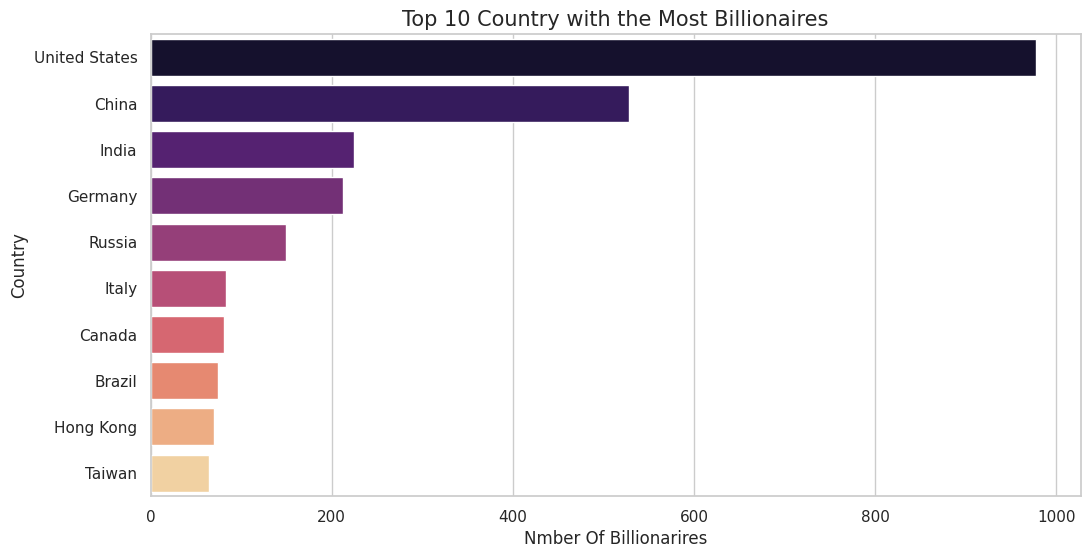

In [21]:
plt.figure(figsize=(12,6))
top_countries=df_aggregate.sort_values('billionaire_count',ascending=False).head(10)

sns.barplot(data=top_countries,x='billionaire_count',y='country',
           hue='country',palette='magma',legend=False)
plt.title('Top 10 Country with the Most Billionaires',fontsize=15)
plt.xlabel('Nmber Of Billionarires')
plt.ylabel('Country')
plt.show()

<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
STEP 07
</span>

### <span style="color:#d63384;">TOP 5 YOUNGEST BILLIONAIRES</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
🧑‍💼 YOUNGEST BILLIONAIRES
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Top 5 Youngest Billionaires
</strong>
</div>

This section highlights the youngest individuals who have achieved billionaire status, showcasing early success and emerging wealth trends.

</details>

</div>

In [22]:
youngest=df_indivisual[df_indivisual['age']>0].sort_values('age').head(5)
print('The Top 5 Youngest Billionaires 2026')
display(youngest[['person_name','age','net_worth_usd_m','country','primary_industry']])

The Top 5 Youngest Billionaires 2026


,person_name,age,net_worth_usd_m,country,primary_industry
3107,Amelie Voigt Trejes,20.0,1165.27,Brazil,Manufacturing
603,Johannes von Baumbach,20.0,6563.45,Germany,Healthcare
2658,Lívia Voigt de Assis,21.0,1460.10,Brazil,Manufacturing
666,Clemente Del Vecchio,21.0,6078.29,Italy,Fashion & Retail
2593,Kim Jung-youn,22.0,1505.49,South Korea,Media & Entertainment


<div style="
  background-color: #1a1a1a;
  color: #eee;
  padding: 15px;
  border-radius: 10px;
  border-right: 6px solid #d63384;
  border-bottom: 6px solid #d63384;
  font-family: 'Courier New', monospace;
  box-shadow: 4px 4px 8px rgba(214, 51, 132, 0.4);
">

<span style="
  background: #d63384;
  color: #fff;
  padding: 2px 8px;
  font-weight: bold;
  border-radius: 3px;
  font-size: 12px;
">
FINAL STEP
</span>

### <span style="color:#d63384;">CONCLUSION</span>

<details>
<summary style="color: #d63384; cursor: pointer; font-weight: bold;">
📌 KEY INSIGHTS
</summary>

<div style="margin-top: 12px; padding: 10px; background: #2a2a2a; border-left: 4px solid #d63384; border-radius: 5px;">
<strong style="color: #d63384;">
Summary of Findings
</strong>
</div>

<ul style="margin-top: 10px; line-height: 1.6;">
<li><strong>Geographic Dominance:</strong> The United States remains the global leader in billionaire wealth, followed by China and India. The interactive map shows that while billionaires are found globally, wealth is heavily concentrated in a few major economies.</li>

<li><strong>Top Industries:</strong> The Technology and Finance sectors continue to be the primary "billionaire factories," producing more high-net-worth individuals than any other industries.</li>

<li><strong>The Next Generation:</strong> While the average billionaire is in their 60s, the Top 5 Youngest Billionaires (such as Amelie Voigt Trejes and Johannes von Baumbach) highlight how significant wealth is emerging in the early 20s, often driven by manufacturing and healthcare sectors.</li>
</ul>

</details>

</div>